In [1]:
import os
os.chdir('../..')

# This workbook contains results for the Euclidean baseline clustering

In [2]:
import chemiscope
from ase import Atoms  
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import polars as pl
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.decomposition import PCA
from src.datasets import QM9Dataset
from sklearn.manifold import TSNE

2026-02-20 10:35:15.609 | INFO     | utils.file_ops:get_device:36 - Using Apple Silicon (MPS)


In [3]:
qm9 = QM9Dataset()
qm9.load()
qm9.add_morgan_fingerprints()
qm9.add_selfies_onehot()
qm9.add_selfies_transformer()
qm9.add_chemprop()
qm9.add_soap()
qm9.add_acsf()

2026-02-20 10:35:17.030 | INFO     | src.datasets:load:65 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-02-20 10:35:17.037 | INFO     | src.features:compute_morgan_fingerprints:56 - Computing Morgan Fingerprints (Radius=3, Size=2048)...
2026-02-20 10:35:20.186 | INFO     | src.features:compute_selfies_onehot:93 - Computing One-Hot Encodings...
2026-02-20 10:35:20.681 | INFO     | src.features:compute_selfies_transformer:68 - Computing Transformer Embeddings (seyonec/ChemBERTa-zinc-base-v1)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

2026-02-20 10:35:59.986 | INFO     | src.features:compute_chemprop_embeddings:179 - Computing Chemprop embeddings on mps...
2026-02-20 10:35:59.987 | WARNING  | src.features:compute_chemprop_embeddings:187 - No model_path provided. Using RANDOM (untrained) MPNN weights.
2026-02-20 10:36:01.335 | INFO     | src.features:compute_soap:116 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-02-20 10:36:06.808 | SUCCESS  | src.datasets:add_soap:216 - Added SOAP embeddings.
2026-02-20 10:36:06.808 | INFO     | src.features:compute_acsf:146 - Computing ACSF (rcut=6.0)...
2026-02-20 10:36:11.007 | SUCCESS  | src.datasets:add_acsf:226 - Added ACSF embeddings.


In [4]:
qm9.df

mol_id,smiles,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,main_chain_length,raw_token_count,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,morgan_fingerprint,selfies_onehot,selfies_transformer,chemprop_embedding,soap_embedding,acsf_embedding
str,str,str,str,i64,str,f64,f64,f64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i8],list[list[i64]],list[f64],list[f64],list[f64],list[f64]
"""qm9_261""","""[H]N([H])C(=O)C([H])([H])OC([H…","""[H]N([H])C(=O)C([H])([H])OC([H…","""[H][N][Branch1][C][H][C][=Bran…",13,"""Acyclic""",89.094,-0.8819,52.32,6,0,0,3,0.666667,1,2,4,0,6,25,0,0,0,1,1,0,0,0,1,0,3,4.2922,47.529999,-6.704885,0.745592,7.450477,706.14032,2.894203,-8806.729492,-8806.52832,-8806.501953,-8807.601562,24.375,-51.323429,-51.622589,-51.93103,-47.75618,9.29932,1.99725,1.69178,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.559326, -0.209692, … 0.512005]","[0.038695, 0.0, … 0.0]","[0.124424, 0.333754, … 0.0]","[3.107281, 1.062942, … 0.0]"
"""qm9_9""","""[H]C([H])([H])C#N""","""[H]C([H])([H])C#N""","""[H][C][Branch1][C][H][Branch1]…",6,"""Acyclic""",41.053,0.52988,23.79,3,0,0,0,0.5,0,1,1,1,3,10,0,0,0,0,0,0,0,0,0,0,1,3.8266,24.450001,-8.881797,1.023148,9.904944,160.722305,1.232295,-3611.444824,-3611.347412,-3611.321533,-3612.097656,10.287,-25.576691,-25.710327,-25.838846,-24.159279,159.035675,9.22327,9.22324,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.808354, -0.308648, … 1.201572]","[0.048552, 0.0, … 0.0]","[0.115668, 0.305562, … 0.0]","[1.848344, 1.003772, … 0.0]"
"""qm9_879""","""[H]C1=C([H])N(C([H])([H])[H])C…","""[H]c1c(N([H])[H])c([H])n(C([H]…","""[H][C][C][Branch1][=Branch1][N…",15,"""Aromatic""",96.133,0.6073,30.95,7,1,1,2,0.2,1,2,7,0,6,29,0,0,0,1,0,0,0,0,0,0,2,1.8575,64.760002,-4.677637,1.428598,6.106235,773.112976,3.444444,-8291.973633,-8291.77832,-8291.75293,-8292.823242,26.188,-63.148518,-63.530945,-63.890789,-58.881283,6.88602,2.02282,1.58289,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.474658, -0.11894, … 0.289242]","[0.029172, 0.018556, … 0.005815]","[0.123825, 0.334222, … 0.0]","[3.045083, 0.918204, … 0.0]"
"""qm9_1367""","""[H]C#CC([H])([H])[C@@]([H])(C(…","""[H]C#CC([H])([H])[C@@]([H])(C(…","""[H][C][#C][C][Branch1][C][H][B…",15,"""Acyclic""",96.129,0.8447,17.07,7,0,0,3,0.5,0,1,4,2,6,29,0,0,0,0,0,0,0,0,0,0,1,2.2671,63.740002,-6.857269,-0.753755,6.103514,952.171814,3.31402,-8394.630859,-8394.40625,-8394.379883,-8395.529297,28.608,-63.936234,-64.289497,-64.64933,-59.733788,6.14001,1.3783,1.21574,"[0, 1, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.430879, -0.32133, … 0.127966]","[0.013976, 0.0, … 0.004733]","[0.123665, 0.334988, … 0.0]","[3.552306, 0.965528, … 0.0]"
"""qm9_1003""","""[H]C(=O)C1=NC([H])=C([H])O1""","""[H]C(=O)c1nc([H])c([H])o1""","""[H][C][=Branch1][C][=O][C][=N]…",10,"""Aromatic""",97.073,0.4871,43.1,7,1,1,1,0.0,0,3,4,0,5,18,0,0,0,0,0,0,0,0,0,0,3,4.3222,52.75,-7.31442,-2.152421,5.162,660.345093,1.842782,-9778.296875,-9778.149414,-9778.123047,-9779.097656,18.813999,-47.480225,-47.71822,-47.949459,-44.604774,8.58513,2.10593,1.6911,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.497694, -0.106939, … 0.760697]","[0.038777, 0.0, … 0.016037]","[0.070166, 0.193362, … 0.0]","[1.209693, 0.40302, … 0.0]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_1799""","""[H]C1=C([H])[C@@]([H])(C([H])(…","""[H]C1=C([H])[C@@]([H])(C([H])(…","""[H][C][=C][Branch1][C][H][C@@]…",15,"""Aliphatic Ring""",96.129,1.1515,17.07,7,1,0,1,0.5,0,1,6,0,5,31,0,0,0

In [5]:
X_morgan = np.array(qm9.df['morgan_fingerprint'].to_list())
X_onehot = np.array(qm9.df['selfies_onehot'].to_list())
X_onehot = X_onehot.reshape(X_onehot.shape[0], -1)
X_transformer = np.array(qm9.df["selfies_transformer"].to_list())
X_chemprop = np.array(qm9.df["chemprop_embedding"].to_list())
X_soap = np.array(qm9.df["soap_embedding"].to_list())
X_acsf = np.array(qm9.df["acsf_embedding"].to_list())

In [6]:

model = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_onehot = model.fit_predict(X_onehot)
labels_morgan = model.fit_predict(X_morgan)
labels_transformer = model.fit_predict(X_transformer)
labels_chemprop = model.fit_predict(X_chemprop)
labels_soap = model.fit_predict(X_soap)
labels_acsf = model.fit_predict(X_acsf)

qm9.df = qm9.df.with_columns(
    onehot_labels=labels_onehot,
    morgan_labels=labels_morgan,
    transformer_labels = labels_transformer,
    chemprop_labels = labels_chemprop,
    soap_labels = labels_soap,
    acsf_labels = labels_acsf
)

In [ ]:
df = qm9.df.drop("morgan_fingerprint", "selfies_onehot", "selfies_transformer", "chemprop_embedding", "soap_embedding", "acsf_embedding")

df.write_csv('report/euclidean_baseline/figures/qm9_clusterlabels.csv')

In [12]:

def get_structures():
    # Extract both the IDs and the SMILES strings
    mol_ids = qm9.df["mol_id"].to_list()
    smiles_list = qm9.df["canonical_smiles"].to_list()
    
    structures = []  
    valid_indices = [] # We need to track this (see warning below)
    
    for i, (mol_id, s) in enumerate(zip(mol_ids, smiles_list)):
        if s is None:
            print(f"Skipping {mol_id}: SMILES is missing.")
            continue
            
        mol = Chem.MolFromSmiles(s)
        if mol is None: 
            print(f"Skipping {mol_id}: RDKit could not parse SMILES.")
            continue
            
        mol = Chem.AddHs(mol)

        res = AllChem.EmbedMolecule(mol, AllChem.ETKDG())
        if res != 0: 
            print(f"Skipping {mol_id}: Failed to generate 3D conformer.")
            continue

        conf = mol.GetConformer()
        positions = conf.GetPositions()
        numbers = [a.GetAtomicNum() for a in mol.GetAtoms()]
        
        atoms = Atoms(numbers=numbers, positions=positions)
        structures.append(atoms)
        valid_indices.append(i)
        
    return structures, valid_indices


structures, valid_indicies = get_structures()

X = X_onehot
X = X[valid_indicies]
model = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = model.fit_predict(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

properties = {
    "PCA 1": X_pca[:, 0],
    "PCA 2": X_pca[:, 1],
    "Cluster": labels,
}

output_path = "report/euclidean_baseline/figures/visualization.json.gz"

chemiscope.write_input(
    output_path,
    structures=structures,
    properties=properties,
)


- Oxygen: Red
- Nitrogen: Blue
- Hydrogen: White
- Sulfur: Yellow
- Carbon : Grey / Black

In [13]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'visualization'}, structures=[{'size': 11, 'data': 'structure-0'}, {'size': 9,…

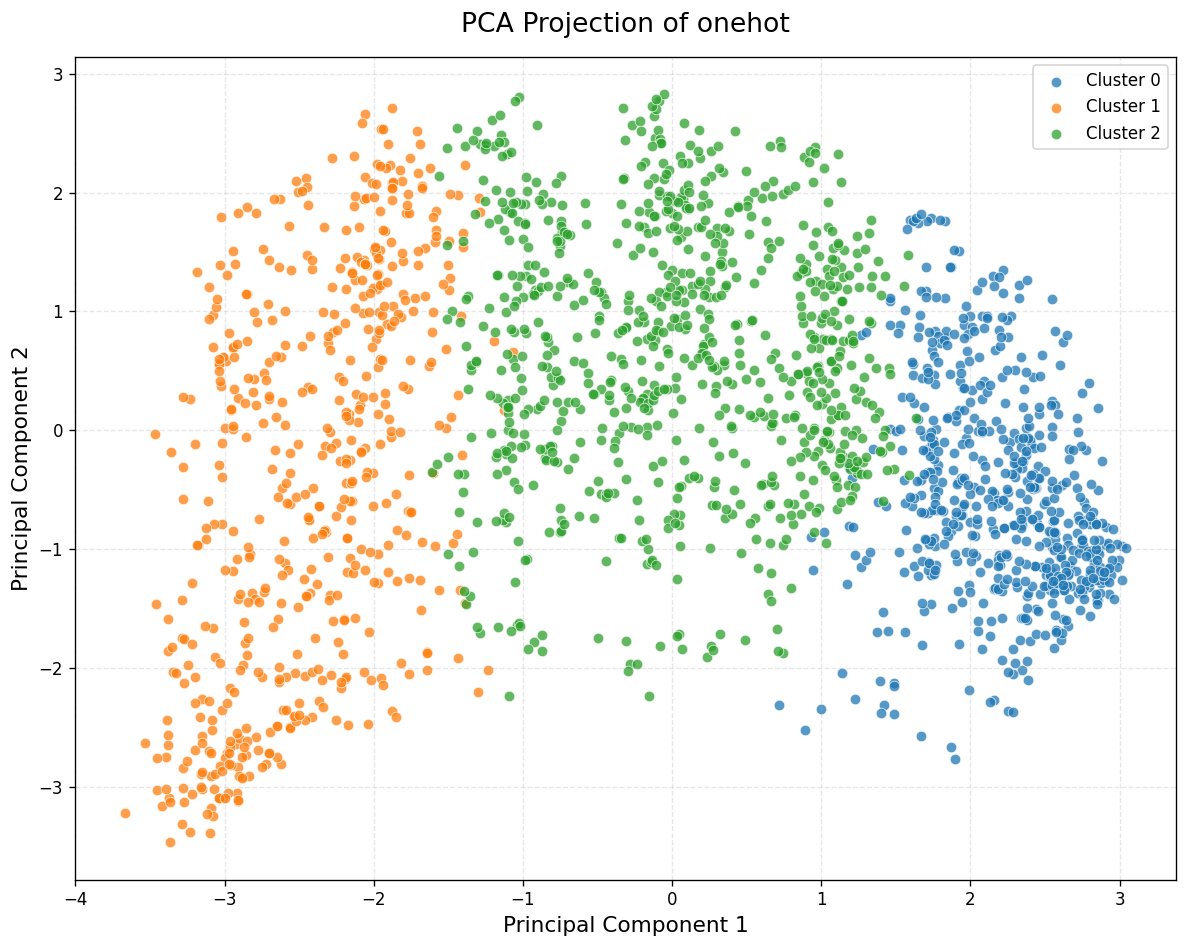

In [15]:
def plot_clusters(data, emb):
    
    x = data["PCA 1"]
    y = data["PCA 2"]
    clusters = data["Cluster"]

    plt.figure(figsize=(10, 8), dpi=120)

    unique_clusters = np.unique(clusters)
    cmap = plt.get_cmap("tab10")

    for i, cluster_id in enumerate(unique_clusters):
        mask = clusters == cluster_id
        plt.scatter(
            x[mask],
            y[mask],
            s=40,
            alpha=0.75,
            label=f"Cluster {cluster_id}",
            color=cmap(i),
            edgecolors="white",
            linewidth=0.5
        )

    # Styling
    plt.title(f"PCA Projection of {emb}", fontsize=16, pad=15)
    plt.xlabel("Principal Component 1", fontsize=13)
    plt.ylabel("Principal Component 2", fontsize=13)

    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend(frameon=True)
    plt.tight_layout()

    plt.savefig(f"report/euclidean_baseline/figures/pca_clusters_{emb}.png", dpi=300)

    plt.show()

plot_clusters(properties, "onehot")